In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [ ]:
df = pd.read_csv('/content/car data.csv')

print(df.head())

  Car_Name  Year  Selling_Price  Present_Price  Driven_kms Fuel_Type  \
0     ritz  2014           3.35           5.59       27000    Petrol   
1      sx4  2013           4.75           9.54       43000    Diesel   
2     ciaz  2017           7.25           9.85        6900    Petrol   
3  wagon r  2011           2.85           4.15        5200    Petrol   
4    swift  2014           4.60           6.87       42450    Diesel   

  Selling_type Transmission  Owner  
0       Dealer       Manual      0  
1       Dealer       Manual      0  
2       Dealer       Manual      0  
3       Dealer       Manual      0  
4       Dealer       Manual      0  


In [ ]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 301 entries, 0 to 300
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Car_Name       301 non-null    object 
 1   Year           301 non-null    int64  
 2   Selling_Price  301 non-null    float64
 3   Present_Price  301 non-null    float64
 4   Driven_kms     301 non-null    int64  
 5   Fuel_Type      301 non-null    object 
 6   Selling_type   301 non-null    object 
 7   Transmission   301 non-null    object 
 8   Owner          301 non-null    int64  
dtypes: float64(2), int64(3), object(4)
memory usage: 21.3+ KB
None


In [ ]:
le = LabelEncoder()

df['Car_Name'] = le.fit_transform(df['Car_Name'])
df['Fuel_Type'] = le.fit_transform(df['Fuel_Type'])
df['Selling_type'] = le.fit_transform(df['Selling_type'])
df['Transmission'] = le.fit_transform(df['Transmission'])

print(df.head())

   Car_Name  Year  Selling_Price  Present_Price  Driven_kms  Fuel_Type  \
0        90  2014           3.35           5.59       27000          2   
1        93  2013           4.75           9.54       43000          1   
2        68  2017           7.25           9.85        6900          2   
3        96  2011           2.85           4.15        5200          2   
4        92  2014           4.60           6.87       42450          1   

   Selling_type  Transmission  Owner  
0             0             1      0  
1             0             1      0  
2             0             1      0  
3             0             1      0  
4             0             1      0  


In [ ]:
df['Car_Age'] = 2026 - df['Year']

print(df[['Year', 'Car_Age']].head())

   Year  Car_Age
0  2014       12
1  2013       13
2  2017        9
3  2011       15
4  2014       12


In [ ]:
X = df.drop(['Selling_Price'], axis=1)

y = df['Selling_Price']

print(X.head())

   Car_Name  Year  Present_Price  Driven_kms  Fuel_Type  Selling_type  \
0        90  2014           5.59       27000          2             0   
1        93  2013           9.54       43000          1             0   
2        68  2017           9.85        6900          2             0   
3        96  2011           4.15        5200          2             0   
4        92  2014           6.87       42450          1             0   

   Transmission  Owner  Car_Age  
0             1      0       12  
1             1      0       13  
2             1      0        9  
3             1      0       15  
4             1      0       12  


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

print("Data split successfully!")

Data split successfully!


In [ ]:
model = LinearRegression()

model.fit(X_train, y_train)

print("Model Trained Successfully!")

Model Trained Successfully!


In [ ]:
y_pred = model.predict(X_test)

print(y_pred[:5])

[ 2.97491895  8.32612847  6.0161235  -1.38172371  9.27940633]


In [ ]:
print("MAE:", mean_absolute_error(y_test, y_pred))
print("MSE:", mean_squared_error(y_test, y_pred))
print("R2 Score:", r2_score(y_test, y_pred))

MAE: 1.2147329896537642
MSE: 3.5370204237438707
R2 Score: 0.8464540623821207


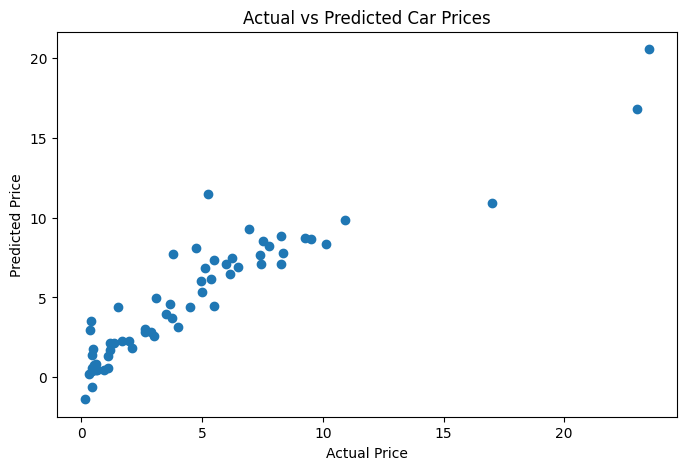

In [ ]:
plt.figure(figsize=(8,5))

plt.scatter(y_test, y_pred)

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted Car Prices")

plt.show()

In [ ]:
impact = pd.DataFrame({
    'Feature': X.columns,
    'Impact': model.coef_
})

print(impact.sort_values(by='Impact', ascending=False))

         Feature    Impact
2  Present_Price  0.440443
1           Year  0.180580
3     Driven_kms -0.000006
0       Car_Name -0.003143
8        Car_Age -0.180580
7          Owner -0.911339
5   Selling_type -1.301768
4      Fuel_Type -1.339365
6   Transmission -1.640356
